# Przewidywanie cen mieszkań na podstawie cech nieruchomości 
Opis: Model uczenia maszynowego przewidujący cenę mieszkania na podstawie liczby 
pokoi, metrażu, lokalizacji itp. 

Used dataset: **Ames Housing Dataset**

In [1]:
import kagglehub
import pandas as pd
import numpy as np
import os

if(not os.path.isdir('data')):
    path = kagglehub.dataset_download("shashanknecrothapa/ames-housing-dataset", output_dir='./data')

    print("Path to dataset:", path)

df = pd.read_csv('./data/AmesHousing.csv')

print(df.shape)  # (2930, 82)
df.head()

(2930, 82)


,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


# Przygotowanie danych

* Obsługa braków w danych
* Zamiana Stringów
* Usuwanie outliersów (Z-score, IQR method, visually)
* Standaryzacja (StandardScaler)
* Numeric skew transforms (log1p)

In [2]:
df.drop(columns=['Order', 'PID', 'Garage Yr Blt', 'Mo Sold', 'Condition 2', 'Roof Matl', 'Heating'], inplace=True)

In [3]:
# Fill categorical "absent" columns with 'None'
none_cols = [ 'Alley', 'Mas Vnr Type', 'Bsmt Qual', 'Bsmt Cond',
                'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin Type 2',
                'Fireplace Qu', 'Garage Type', 'Garage Finish',
                'Garage Qual', 'Garage Cond', 'Pool QC', 'Fence', 'Misc Feature' 
]
df[none_cols] = df[none_cols].fillna('None')

# Fill numeric absent columns with 0
zero_cols = [ 'Lot Frontage', 'Mas Vnr Area', 'BsmtFin SF 1', 'BsmtFin SF 2',
                'Bsmt Unf SF', 'Total Bsmt SF', 'Bsmt Full Bath', 'Bsmt Half Bath',
                'Garage Cars', 'Garage Area' 
]
df[zero_cols] = df[zero_cols].fillna(0)

df['Electrical'] = df['Electrical'].fillna('SBrkr')

In [4]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['SalePrice'])
y = df['SalePrice']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [5]:
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, TargetEncoder

ordinal_cols = {
    'Lot Shape':        ['IR3', 'IR2', 'IR1', 'Reg'],
    'Utilities':        ['ELO', 'NoSeWa', 'NoSewr', 'AllPub'],
    'Land Slope':       ['Gtl', 'Mod', 'Sev'],
    'Exter Qual':       ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
    'Exter Cond':       ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
    'Bsmt Qual':        ['None', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],
    'Bsmt Cond':        ['None', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],
    'Bsmt Exposure':    ['None', 'No', 'Mn', 'Av', 'Gd'],
    'BsmtFin Type 1':   ['None', 'Unf', 'LwQ', 'Rec', 'BLQ', 'ALQ', 'GLQ'],
    'BsmtFin Type 2':   ['None', 'Unf', 'LwQ', 'Rec', 'BLQ', 'ALQ', 'GLQ'],
    'Central Air':      ['N', 'Y'],
    'Electrical':       ['Mix', 'FuseP', 'FuseF', 'FuseA', 'SBrkr'],
    'Kitchen Qual':     ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
    'Functional':       ['Sal', 'Sev', 'Maj2', 'Maj1', 'Mod', 'Min2', 'Min1', 'Typ'],
    'Fireplace Qu':     ['None', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],
    'Garage Finish':    ['None', 'Unf', 'RFn', 'Fin'],
    'Garage Qual':      ['None', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],
    'Garage Cond':      ['None', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],
    'Paved Drive':      ['N', 'P', 'Y'],
    'Pool QC':          ['None', 'Fa', 'TA', 'Gd', 'Ex'],
    'Fence':            ['None', 'MnWw', 'GdWo', 'MnPrv', 'GdPrv'],
    'Heating QC':       [ 'Po', 'Fa', 'TA', 'Gd', 'Ex'],
}

for col, order in ordinal_cols.items():
    enc = OrdinalEncoder(
    categories=[order],
    handle_unknown='use_encoded_value',
    unknown_value=-1         
    )
    X_train[col] = enc.fit_transform(X_train[[col]]).ravel()
    X_test[col] = enc.transform(X_test[[col]]).ravel()

one_hot_cols = [ 'MS Zoning', 'Street', 'Alley', 'Land Contour',
                    'Lot Config', 'Bldg Type', 'House Style', 'Roof Style',
                    'Mas Vnr Type', 'Foundation',
                ]

ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore', dtype=float)

ohe_train = pd.DataFrame(ohe.fit_transform(X_train[one_hot_cols]), columns=ohe.get_feature_names_out(one_hot_cols), index=X_train.index)
ohe_test = pd.DataFrame(ohe.transform(X_test[one_hot_cols]), columns=ohe.get_feature_names_out(one_hot_cols), index=X_test.index)

X_train = pd.concat([X_train.drop(columns=one_hot_cols), ohe_train], axis=1)
X_test = pd.concat([X_test.drop(columns=one_hot_cols), ohe_test], axis=1)


target_cols = [ 'MS SubClass', 'Neighborhood', 'Condition 1', 'Garage Type',
                    'Misc Feature', 'Sale Type', 'Sale Condition', 'Exterior 1st',
                    'Exterior 2nd'
                ]

te = TargetEncoder(target_type="continuous", random_state=42)
X_train[target_cols] = te.fit_transform(X_train[target_cols], y_train)
X_test[target_cols]  = te.transform(X_test[target_cols])

In [6]:
from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.preprocessing import StandardScaler

iso = IsolationForest(
    n_estimators=200,
    contamination=0.05,
    random_state=42,
    n_jobs=-1
)
iso.fit(X_train)

train_iso_mask  = iso.predict(X_train) == -1
train_iso_scores = iso.score_samples(X_train)

test_iso_mask   = iso.predict(X_test) == -1
test_iso_scores  = iso.score_samples(X_test)

print(f"Train outliers: {train_iso_mask.sum()} ({train_iso_mask.mean()*100:.1f}%)")
print(f"Test  outliers: {test_iso_mask.sum()}  ({test_iso_mask.mean()*100:.1f}%)")


Train outliers: 118 (5.0%)
Test  outliers: 33  (5.6%)


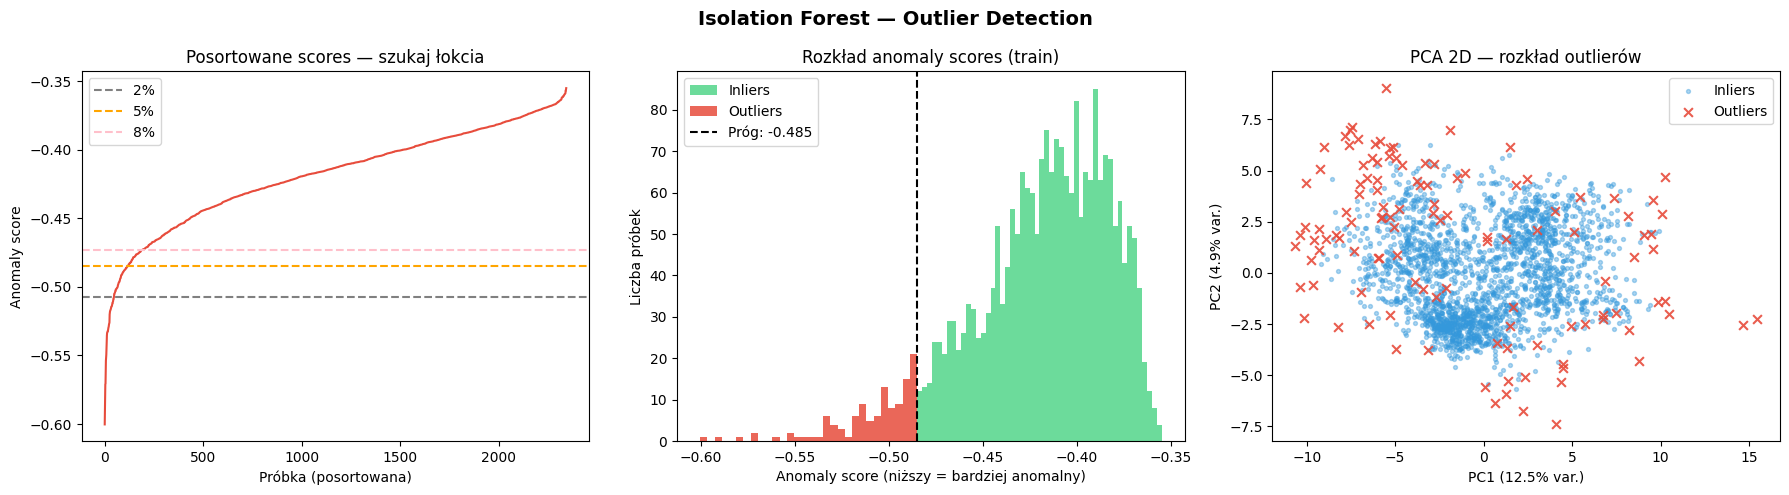

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Isolation Forest — Outlier Detection", fontsize=14, fontweight='bold')

# Elbow method for contamination
scores = iso.score_samples(X_train)
ax = axes[0]
ax.plot(np.sort(scores), color='#e74c3c', linewidth=1.5)
ax.set_title('Posortowane scores — szukaj łokcia')
ax.set_xlabel('Próbka (posortowana)')
ax.set_ylabel('Anomaly score')
ax.axhline(np.percentile(scores, 2), color='gray',
                linestyle='--', label='2%')
ax.axhline(np.percentile(scores, 5), color='orange',
                linestyle='--', label='5%')
ax.axhline(np.percentile(scores, 8), color='pink',
                linestyle='--', label='8%')
ax.legend()

# Histogram anomaly scores
ax = axes[1]
ax.hist(train_iso_scores[~train_iso_mask], bins=50,
        color='#2ecc71', alpha=0.7, label='Inliers')
ax.hist(train_iso_scores[train_iso_mask], bins=30,
        color='#e74c3c', alpha=0.85, label='Outliers')
ax.axvline(iso.offset_, color='black', linestyle='--',
           linewidth=1.5, label=f'Próg: {iso.offset_:.3f}')
ax.set_title('Rozkład anomaly scores (train)')
ax.set_xlabel('Anomaly score (niższy = bardziej anomalny)')
ax.set_ylabel('Liczba próbek')
ax.legend()

# PCA 2D scatter
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(StandardScaler().fit_transform(X_train))

ax = axes[2]
ax.scatter(X_2d[~train_iso_mask, 0], X_2d[~train_iso_mask, 1],
           s=8, alpha=0.4, color='#3498db', label='Inliers')
ax.scatter(X_2d[train_iso_mask, 0], X_2d[train_iso_mask, 1],
           s=40, alpha=0.9, color='#e74c3c', marker='x',
           linewidths=1.5, label='Outliers')
ax.set_title('PCA 2D — rozkład outlierów')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var.)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var.)')
ax.legend()

plt.tight_layout()
# plt.savefig('isolation_forest_outliers.png', dpi=150, bbox_inches='tight')
plt.show()

X_train_clean = X_train[~train_iso_mask]
y_train_clean = y_train[~train_iso_mask]
X_test_clean = X_test[~test_iso_mask]
y_test_clean = y_test[~test_iso_mask]

In [8]:
scaler = StandardScaler()
X_train_clean = scaler.fit_transform(X_train_clean)
X_test_clean = scaler.fit(X_test_clean)

# Wizualizacja danych

* Rozkład ceny (y) — histogram + czy potrzebny log-transform
* Top 20 cech wg korelacji z ceną
* Scatter plots tych cech vs cena
* Macierz korelacji (top 20)
* Wykresy 3D (6 sztuk)
* PCA/t-SNE/UMAP w 2D (kolorowane ceną)